# Training a Neural Network

## 1. What is Neural Network Training?

Training means teaching the neural network to make better predictions.

The basic process is:

Input → Prediction → Loss → Backpropagation → Weight Update

The model starts with randomly initialized weights.

During training, the model makes predictions, calculates how wrong those predictions are, and changes its weights to reduce the error.

### Real-world example

For an online retail company, we can use transaction information to predict whether an order is a high-value order.

The model can use:

- Quantity
- Unit Price
- Purchase Hour
- Purchase Month

### AI/ML usage

Neural network training is used in:

- Image classification
- Fraud detection
- Customer prediction
- Recommendation systems
- Healthcare prediction
- Natural language processing
- Speech recognition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

## 3. Step 1 – Load Data

I am using the Online Retail dataset.

The dataset contains information about:

- Invoice number
- Product
- Quantity
- Invoice date
- Unit price
- Customer
- Country

I will use this dataset to create a simple binary classification problem.

In [2]:
df = pd.read_csv("data.csv", encoding="latin1")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 4. Step 2 – Prepare Features

First, I clean the data.

I calculate:

Total Amount = Quantity × Unit Price

Then I extract:

- Hour
- Month

I will use four features:

1. Quantity
2. UnitPrice
3. Hour
4. Month

### Target

I create a target called `HighValueOrder`.

If the transaction amount is above the median amount:

HighValueOrder = 1

Otherwise:

HighValueOrder = 0

### Real-world example

This is similar to creating a business prediction such as:

"Is this transaction likely to be a high-value transaction?"

In [3]:
df = df.dropna(subset=["Quantity", "UnitPrice", "InvoiceDate"])

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

df["Hour"] = df["InvoiceDate"].dt.hour
df["Month"] = df["InvoiceDate"].dt.month

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Hour,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,12


In [4]:
median_amount = (df["TotalAmount"]).median()

df["HighValueOrder"] = (
    df["TotalAmount"] > median_amount
).astype(int)

print(df["HighValueOrder"].value_counts())


HighValueOrder
0    266446
1    263658
Name: count, dtype: int64


## 6. Create a Smaller Dataset

The original dataset contains many rows.

For this learning example, I will use 20,000 transactions so that the training process is simple and fast.

The important concepts remain the same even when working with a much larger dataset.

In [5]:
df = df.sample(
    n=min(20000, len(df)),
    random_state=42
)

print(df.shape)

(20000, 12)


## 7. Step 3 – Split Data

I divide the data into:

- Training data
- Validation data
- Test data

### Training data

Used to learn the model parameters.

### Validation data

Used to check how the model performs during training.

### Test data

Used for the final evaluation.

### Real-world example

If I build a fraud detection model, I should not evaluate it only using transactions that the model has already seen during training.

### AI/ML usage

Data splitting helps us understand whether a model can generalize to new data.

In [6]:
features = [
    "Quantity",
    "UnitPrice",
    "Hour",
    "Month"
]

X = df[features].values
y = df["HighValueOrder"].values

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 14000
Validation: 3000
Testing: 3000


## 8. Feature Scaling

Our features have different ranges.

For example:

- Month is between 1 and 12
- Quantity can have much larger values
- Unit price can have a different scale

So I standardize the features.

Standardization makes the features easier for the neural network to work with.

The basic formula is:

z = (x - mean) / standard deviation

I fit the scaler only using the training data.

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 9. Step 4 – Create Tensors

PyTorch uses tensors to store data.

A tensor is similar to a NumPy array but is designed for deep learning operations.

I convert the training, validation, and test data into PyTorch tensors.

### AI/ML usage

Tensors are used throughout PyTorch for:

- Input data
- Model parameters
- Predictions
- Gradients

In [9]:
X_train = torch.tensor(X_train,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32).reshape(-1, 1)

X_val = torch.tensor(X_val,dtype=torch.float32)

y_val = torch.tensor(y_val,dtype=torch.float32).reshape(-1, 1)

X_test = torch.tensor(X_test,dtype=torch.float32)

y_test = torch.tensor(y_test,dtype=torch.float32).reshape(-1, 1)

In [10]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: torch.Size([14000, 4])
y_train: torch.Size([14000, 1])


## 10. What is an Epoch?

An epoch means:

**One complete pass through the entire training dataset.**

For example, if I train the model for 10 epochs, the model gets to see the training dataset 10 times.

### Real-world example

If I have 10,000 training transactions and train for 20 epochs, the model processes those training examples repeatedly across 20 complete passes.

### AI/ML usage

Epochs control how many times the model learns from the training dataset.

## 11. What is a Batch?

A batch is a small group of training samples processed together.

Instead of sending the entire dataset into the model at once, I can divide it into smaller batches.

For example:

10,000 samples

Batch size = 64

The model processes around 64 samples at a time.

### Advantages

Batches:

- Use less memory
- Make training faster
- Allow frequent weight updates

### AI/ML usage

Mini-batch training is commonly used when training neural networks.

## 12. What is an Iteration?

An iteration means one update of the model parameters.

One iteration usually looks like:

Batch → Forward Pass → Loss → Backpropagation → Weight Update

For example:

If there are 10,000 samples and the batch size is 100:

Approximately 100 iterations happen in one epoch.

### Simple relationship

Iterations per epoch ≈ Number of samples / Batch size

In [11]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [12]:
train_data = TensorDataset(X_train,y_train)

val_data = TensorDataset(X_val,y_val)

train_loader = DataLoader(train_data,batch_size=64,shuffle=True)

val_loader = DataLoader(val_data,batch_size=64)

print("Number of training batches:", len(train_loader))

Number of training batches: 219


## 14. Step 5 – Create the Neural Network

My model architecture is:

Input → Hidden Layer → ReLU → Hidden Layer → ReLU → Output

Architecture:

4 → 8 → 6 → 1

The four input features are:

- Quantity
- UnitPrice
- Hour
- Month

The output has one neuron because this is a binary classification problem.

In [13]:
class RetailModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(4, 8)
        self.layer2 = nn.Linear(8, 6)
        self.output = nn.Linear(6, 1)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.output(x)

        return x

In [14]:
model = RetailModel()

print(model)

RetailModel(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (output): Linear(in_features=6, out_features=1, bias=True)
  (relu): ReLU()
)


## 16. Step 6 – Loss Function

The loss function tells us how wrong the model prediction is.

For binary classification, I use:

`BCEWithLogitsLoss`

A lower loss generally means the predictions are closer to the target values.

### Real-world example

If the actual answer is:

1 = High-value transaction

but the model predicts a very low probability, the loss will be larger.

### AI/ML usage

Loss functions are used to measure model error.

Examples:

- Binary classification → BCEWithLogitsLoss
- Multi-class classification → CrossEntropyLoss
- Regression → Mean Squared Error

In [15]:
loss_function = nn.BCEWithLogitsLoss()

print(loss_function)

BCEWithLogitsLoss()


## 17. Step 7 – Optimizer

The optimizer updates the model weights using the gradients.

I will use Adam.

Adam is a popular optimizer for neural networks.

### Learning Rate

The learning rate controls the size of each weight update.

I will start with:

Learning rate = 0.001

### If learning rate is too high

The model may learn unstably.

### If learning rate is too low

Training may become very slow.

### AI/ML usage

Common optimizers include:

- SGD
- Adam
- RMSprop
- AdamW

In [16]:
learning_rate = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print("Learning rate:", learning_rate)

Learning rate: 0.001


## 18. Step 8 – Forward Pass

A forward pass means sending the input through the neural network to produce predictions.

The data flows like this:

Input

↓

Linear Layer

↓

ReLU

↓

Linear Layer

↓

ReLU

↓

Output

The output is called a logit in this binary classification example.

In [17]:
sample = X_train[:5]

output = model(sample)

print(output)

tensor([[-0.4383],
        [-0.3361],
        [-0.3520],
        [-0.3324],
        [-0.3517]], grad_fn=<AddmmBackward0>)


## 19. Step 9 – Calculate Loss

After getting the predictions, I compare them with the actual answers.

The loss function gives me a number representing the error.

The goal of training is to reduce this loss.

In [19]:
sample_target = y_train[:5]

loss = loss_function(
    output,
    sample_target
)

print("Loss:", loss.item())

Loss: 0.5958023071289062


## 20. Step 10 – Backpropagation

Backpropagation calculates the gradients of the loss.

The gradients tell the optimizer how the model parameters should change.

In PyTorch, I use:

`loss.backward()`

This calculates gradients for the trainable parameters.

In [21]:
optimizer.zero_grad()

loss.backward()

print("Gradients calculated")

Gradients calculated


## 21. Step 11 – Update Weights

After calculating gradients, the optimizer updates the model parameters.

I use:

`optimizer.step()`

This is the actual weight update step.

The optimizer uses the learning rate and gradients to modify the weights.

In [23]:
optimizer.step()

print("Weights updated")

Weights updated


## 22. Complete Training Loop

Now I combine all the steps.

For every batch:

1. Clear old gradients
2. Forward pass
3. Calculate loss
4. Backpropagation
5. Update weights

Then I repeat this for multiple epochs.

I will also calculate validation loss after every epoch.

In [25]:
model = RetailModel()

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 20

train_losses = []
val_losses = []

In [26]:
for epoch in range(epochs):

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = loss_function(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    average_train_loss = (
        total_train_loss / len(train_loader)
    )

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            predictions = model(X_batch)

            loss = loss_function(
                predictions,
                y_batch
            )

            total_val_loss += loss.item()

    average_val_loss = (
        total_val_loss / len(val_loader)
    )

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    print(
        "Epoch:",
        epoch + 1,
        "Training Loss:",
        round(average_train_loss, 4),
        "Validation Loss:",
        round(average_val_loss, 4)
    )

Epoch: 1 Training Loss: 0.6834 Validation Loss: 0.6509
Epoch: 2 Training Loss: 0.565 Validation Loss: 0.4626
Epoch: 3 Training Loss: 0.4011 Validation Loss: 0.3535
Epoch: 4 Training Loss: 0.3329 Validation Loss: 0.315
Epoch: 5 Training Loss: 0.3102 Validation Loss: 0.303
Epoch: 6 Training Loss: 0.2976 Validation Loss: 0.2928
Epoch: 7 Training Loss: 0.2856 Validation Loss: 0.2802
Epoch: 8 Training Loss: 0.272 Validation Loss: 0.2668
Epoch: 9 Training Loss: 0.2596 Validation Loss: 0.2541
Epoch: 10 Training Loss: 0.247 Validation Loss: 0.2417
Epoch: 11 Training Loss: 0.2341 Validation Loss: 0.2279
Epoch: 12 Training Loss: 0.2194 Validation Loss: 0.2124
Epoch: 13 Training Loss: 0.2021 Validation Loss: 0.1909
Epoch: 14 Training Loss: 0.1832 Validation Loss: 0.1738
Epoch: 15 Training Loss: 0.1654 Validation Loss: 0.155
Epoch: 16 Training Loss: 0.149 Validation Loss: 0.1397
Epoch: 17 Training Loss: 0.1349 Validation Loss: 0.1285
Epoch: 18 Training Loss: 0.122 Validation Loss: 0.1166
Epoch: 19

## 24. Training Loss vs Epoch

Training loss tells me how well the model is fitting the training data.

If the training loss decreases:

- The model is learning
- Predictions are becoming closer to the training targets

The x-axis represents epochs.

The y-axis represents loss.

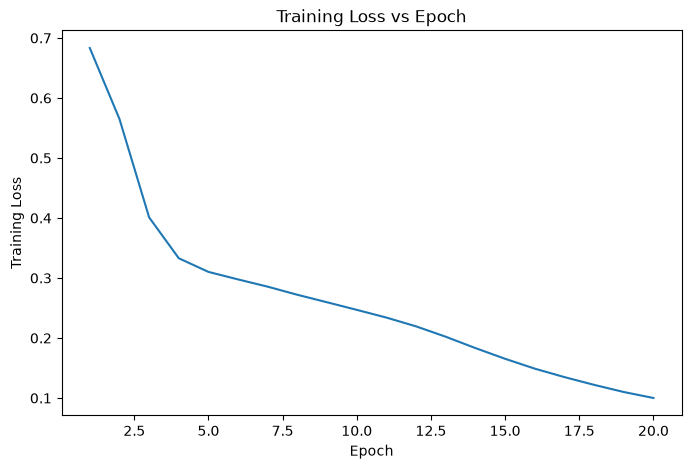

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")

plt.show()

## 25. Validation Loss vs Epoch

Validation loss shows how the model performs on validation data.

The validation data is not used to update the weights.

This makes validation loss useful for checking generalization.

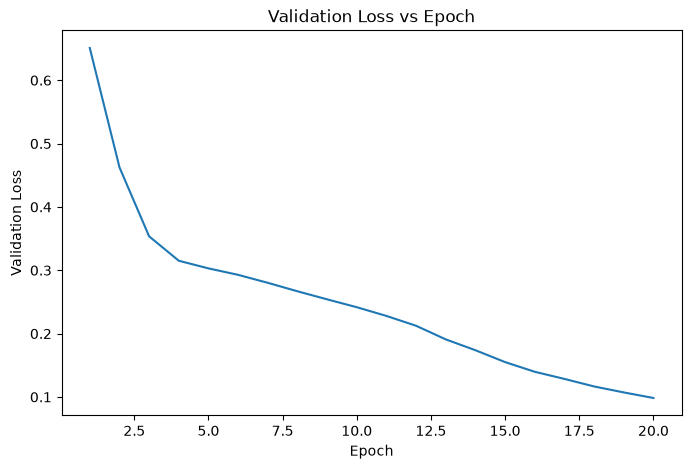

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    val_losses
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")

plt.show()

## 26. Training Loss vs Validation Loss

Now I plot both curves together.

### If both losses decrease

The model is learning and validation performance is also improving.

### If training loss decreases but validation loss increases

This can be a sign of overfitting.

The model may be learning the training data too specifically.

### If both losses remain high

The model may not be learning the problem effectively.

Possible reasons include:

- Poor features
- Learning rate problems
- Not enough training
- Model architecture
- Difficult prediction problem

### Important

The curves should be interpreted together with the dataset and other evaluation metrics.

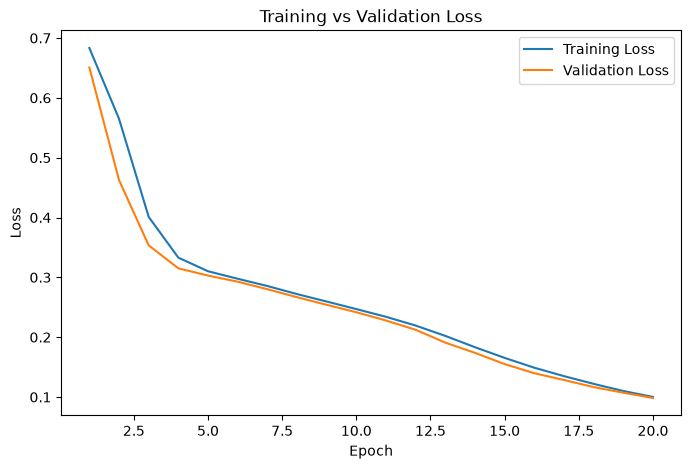

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

## 27. What Does the Loss Curve Tell Me?

### Situation 1

Training Loss ↓  
Validation Loss ↓

The model is generally learning useful patterns.

### Situation 2

Training Loss ↓  
Validation Loss ↑

This can indicate overfitting.

### Situation 3

Training Loss stays high  
Validation Loss stays high

The model may not be learning effectively.

### Situation 4

Loss decreases very slowly

The learning rate may be too small or the model may need other changes.

### Situation 5

Loss changes dramatically

The learning rate may be too large or the training process may be unstable.

The exact interpretation depends on the problem and experiment.

## 28. Understanding Learning Rate

Learning rate controls how much the model changes its weights after calculating gradients.

For example:

Learning rate = 0.001

means the optimizer makes relatively small parameter updates.

### Large learning rate

Large steps

→ Can learn quickly

→ Can become unstable

### Small learning rate

Small steps

→ More gradual learning

→ Can take longer

### AI/ML usage

Learning rate is one of the most important hyperparameters when training neural networks.

## 29. Final Test

After training is complete, I evaluate the model using the test data.

The test data was not used to update the model weights.

In [30]:
model.eval()

with torch.no_grad():

    test_output = model(X_test)

    probabilities = torch.sigmoid(
        test_output
    )

    predictions = (
        probabilities >= 0.5
    ).float()

accuracy = (
    predictions == y_test
).float().mean()

print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.9789999723434448
